# Introduction

L’assurance automobile génère des volumes importants de données hétérogènes, décrivant à la fois les caractéristiques des assurés, des véhicules, des contrats et des sinistres. Dans ce contexte, l’identification de profils homogènes au sein d’un portefeuille constitue un enjeu majeur pour les assureurs, que ce soit pour la compréhension du risque, le pilotage de la rentabilité ou l’adaptation des politiques de tarification et de souscription.

Les méthodes de machine learning non supervisé offrent un cadre particulièrement adapté à ce type de problématique. En l’absence de variable cible clairement définie, elles permettent d’explorer la structure latente des données et de regrouper les observations selon des similarités multidimensionnelles, sans imposer a priori une segmentation prédéfinie. Ces approches sont ainsi largement utilisées pour la segmentation de portefeuilles, la détection de comportements atypiques ou l’analyse exploratoire de bases de données complexes.

L’objectif de ce travail est d’appliquer et de comparer plusieurs techniques de clustering non supervisé sur un portefeuille d’assurance automobile réel. À partir d’un jeu de données comprenant des variables numériques, catégorielles et temporelles, une méthodologie complète est mise en œuvre : préparation et transformation des données, réduction de dimension, segmentation par différents algorithmes et interprétation économique des résultats.

L’accent est mis sur la rigueur méthodologique et sur la cohérence économique des segments obtenus. Au-delà de la performance statistique des modèles, l’enjeu est de produire une typologie de contrats interprétable et exploitable du point de vue assurantiel, tout en discutant les limites inhérentes aux approches non supervisées.


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Chargement (IMPORTANT: sep=';') ----
DATA_PATH = "Motor vehicle insurance data.csv"
df_raw = pd.read_csv(DATA_PATH, sep=";", low_memory=False)

print("Shape:", df_raw.shape)
display(df_raw.head(3))
print("\nDtypes:\n", df_raw.dtypes)


Shape: (105555, 30)


,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190



Dtypes:
 ID                        int64
Date_start_contract      object
Date_last_renewal        object
Date_next_renewal        object
Date_birth               object
Date_driving_licence     object
Distribution_channel     object
Seniority                 int64
Policies_in_force         int64
Max_policies              int64
Max_products              int64
Lapse                     int64
Date_lapse               object
Payment                   int64
Premium                 float64
Cost_claims_year        float64
N_claims_year             int64
N_claims_history          int64
R_Claims_history        float64
Type_risk                 int64
Area                      int64
Second_driver             int64
Year_matriculation        int64
Power                     int64
Cylinder_capacity         int64
Value_vehicle           float64
N_doors                   int64
Type_fuel                object
Length                  float64
Weight                    int64
dtype: object


# Cellule 1 — Imports et chargement des données : vérifications et résultats

Cette première cellule a deux objectifs : (i) importer l’environnement Python nécessaire à l’analyse non supervisée, (ii) charger correctement le jeu de données et vérifier que l’importation est conforme (dimension, structure, types).

1) Importation des bibliothèques  
Les bibliothèques importées structurent le pipeline de bout en bout :
- `pandas`, `numpy` : manipulation de données, contrôles de cohérence, calculs.
- `matplotlib` : visualisations simples (diagnostics, projections, courbes de métriques).
- `sklearn` : prétraitement (imputation, normalisation, encodage), réduction de dimension, clustering et métriques internes.
Le paramètre `RANDOM_STATE = 42` fixe l’aléa (initialisations, sous-échantillonnages) afin d’assurer la reproductibilité des résultats.

2) Chargement du fichier et point critique du séparateur  
Le fichier est chargé via :
- `pd.read_csv("Motor vehicle insurance data.csv", sep=";")`.
Le séparateur `sep=";"` est déterminant : le dataset est fourni au format CSV avec séparateur point-virgule. Sans ce paramètre, l’importation conduit typiquement à une seule colonne (toute la ligne lue comme une chaîne), ce qui invaliderait toute l’analyse.

3) Contrôles de cohérence attendus en sortie  
Les impressions suivantes servent de tests de validation (sanity checks) :
- `Shape` : doit indiquer un ordre de grandeur autour de 10^5 lignes et une trentaine de colonnes. Cela confirme que l’import n’a pas tronqué le fichier et que la séparation en colonnes a bien fonctionné.
- `head()` : permet de vérifier visuellement la présence de variables de différentes natures (numériques, catégorielles, dates) et de confirmer que les valeurs ne sont pas décalées (erreur classique en cas de mauvais séparateur).
- `dtypes` : met en évidence :
  - des variables numériques (`int`, `float`) prêtes à être normalisées/standardisées,
  - des variables catégorielles (`object`) qui devront être encodées (One-Hot),
  - des colonnes de dates souvent importées en `object` et qui nécessiteront une conversion explicite dans les cellules suivantes.

Conclusion (Cellule 1)  
Les résultats de cette cellule sont cohérents si (i) la dimension du dataset est plausible, (ii) les colonnes apparaissent correctement séparées, (iii) la typologie des variables est hétérogène (numérique/catégorielle/temporelle), ce qui justifie la mise en place d’un pipeline de prétraitement avant toute méthode de clustering.


In [4]:
df = df_raw.copy()

# Dates au format jj/mm/aaaa
date_cols = [
    "Date_start_contract","Date_last_renewal","Date_next_renewal",
    "Date_birth","Date_driving_licence","Date_lapse"
]
for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], format="%d/%m/%Y", errors="coerce")

# Référence temporelle: date de renouvellement la plus récente observée (pratique et reproductible)
ref_date = df["Date_last_renewal"].max()

# Feature engineering "assurance"
df["age"] = (ref_date - df["Date_birth"]).dt.days / 365.25
df["licence_tenure"] = (ref_date - df["Date_driving_licence"]).dt.days / 365.25
df["contract_tenure"] = (ref_date - df["Date_start_contract"]).dt.days / 365.25

# Indicateurs sinistres utiles (si pas déjà “propres”)
# (Les colonnes existent déjà : N_claims_year, Cost_claims_year, N_claims_history, R_Claims_history)
# On peut aussi créer une fréquence/gravité proxy (attention aux zéros)
df["claims_freq_proxy"] = df["N_claims_year"]
df["claims_sev_proxy"] = df["Cost_claims_year"] / (df["N_claims_year"].replace(0, np.nan))
df["claims_sev_proxy"] = df["claims_sev_proxy"].fillna(0)

# Nettoyages de base
# - On enlève l'ID et les dates brutes (on garde les features construites)
drop_cols = ["ID"] + date_cols
drop_cols = [c for c in drop_cols if c in df.columns]
df_model = df.drop(columns=drop_cols)

print("Shape après features:", df_model.shape)
display(df_model.head(3))


Shape après features: (105555, 28)


,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Cost_claims_year,N_claims_year,...,Value_vehicle,N_doors,Type_fuel,Length,Weight,age,licence_tenure,contract_tenure,claims_freq_proxy,claims_sev_proxy
0,0,4,1,2,1,0,0,222.52,0.0,0,...,7068.0,0,P,NaN,190,62.625599,42.696783,3.069131,0,0.0
1,0,4,1,2,1,0,0,213.78,0.0,0,...,7068.0,0,P,NaN,190,62.625599,42.696783,3.069131,0,0.0
2,0,4,2,2,1,0,0,214.84,0.0,0,...,7068.0,0,P,NaN,190,62.625599,42.696783,3.069131,0,0.0


# Cellule 2 — Conversion des dates et feature engineering : cohérence des résultats

Cette cellule prépare l’information temporelle et construit des variables “métier” (assurance auto) plus interprétables et mieux adaptées au clustering. Elle répond à deux enjeux : (i) rendre les dates exploitables, (ii) transformer des dates brutes en indicateurs continus (âges, anciennetés) qui capturent la structure de risque.

## 1) Conversion des variables de dates

Les colonnes de dates (début de contrat, renouvellement, naissance, permis, résiliation, etc.) sont converties au format `datetime` avec :
- un format explicite `"%d/%m/%Y"` (adapté au format français/espagnol du fichier),
- `errors="coerce"` : toute valeur mal formée est convertie en `NaT` (valeur manquante temporelle).

Interprétation attendue :
- la conversion réussit si ces colonnes passent de type `object` à `datetime64[ns]`,
- la présence éventuelle de `NaT` n’est pas une erreur : elle signale des dates manquantes ou incohérentes, qui seront gérées ensuite (imputation, exclusion ciblée, ou robustesse du modèle).

## 2) Choix d’une date de référence (`ref_date`)

On définit une date de référence comme la date de renouvellement la plus récente observée :
- `ref_date = max(Date_last_renewal)`.

C’est un choix cohérent économiquement :
- il revient à “photographier” le portefeuille à sa date d’observation la plus récente,
- il permet de calculer des âges/anciennetés comparables entre assurés,
- il évite d’utiliser la date système (qui introduit un décalage si le notebook est rejoué plus tard).

## 3) Construction de variables continues pertinentes (métier)

Trois variables structurantes sont créées :

- **Âge de l’assuré**  
  \[
  age = \frac{ref\_date - Date\_birth}{365.25}
  \]
  Interprétation : proxy central du risque (expérience, comportement, exposition).

- **Ancienneté de permis**  
  \[
  licence\_tenure = \frac{ref\_date - Date\_driving\_licence}{365.25}
  \]
  Interprétation : mesure l’expérience de conduite ; on s’attend généralement à une relation négative avec le risque (toutes choses égales par ailleurs), surtout pour certains segments.

- **Ancienneté de contrat**  
  \[
  contract\_tenure = \frac{ref\_date - Date\_start\_contract}{365.25}
  \]
  Interprétation : capte la fidélité/ancienneté ; peut se corréler à la stabilité du portefeuille, au niveau de prime, ou au comportement de déclaration.

Cohérence attendue sur les résultats :
- `age` doit être majoritairement positif (valeurs négatives = dates incohérentes à investiguer),
- `licence_tenure` doit être en moyenne inférieur à `age` (puisque permis après naissance),
- `contract_tenure` est typiquement plus faible que `licence_tenure`.

## 4) Variables sinistres : fréquence et gravité (proxies)

Deux proxys sont ajoutés :

- **Fréquence (proxy)** : `claims_freq_proxy = N_claims_year`  
  Interprétation : nombre de sinistres observés sur l’année ; distribution souvent très asymétrique (beaucoup de zéros).

- **Gravité (proxy)** :  
  \[
  claims\_sev\_proxy = \frac{Cost\_claims\_year}{N\_claims\_year}
  \]
  avec gestion robuste des zéros via remplacement de 0 par `NaN` puis remise à 0 si pas de sinistre.

Interprétation attendue :
- pour la majorité des contrats sans sinistre, fréquence = 0 et gravité = 0,
- pour les contrats sinistrés, gravité strictement positive et potentiellement très dispersée (queue lourde).

## 5) Nettoyage : suppression des dates brutes et de l’identifiant

On retire :
- `ID` (identifiant sans valeur économique pour un clustering),
- les dates brutes (qui seraient mal exploitées en clustering car non normalisées et susceptibles de créer des effets artificiels),
tout en conservant l’information via les variables construites (âge, anciennetés, etc.).

## Conclusion (Cellule 2)

Les résultats sont cohérents si :
- les colonnes de dates sont bien converties en `datetime`,
- les variables `age`, `licence_tenure`, `contract_tenure` présentent des ordres de grandeur plausibles (valeurs positives, hiérarchie logique),
- les proxys sinistres gèrent correctement les cas `N_claims_year = 0`,
- les dates brutes et l’ID sont supprimés du dataset final destiné au clustering afin d’éviter des segments artificiels.


In [ ]:
# On identifie automatiquement les types
num_cols = df_model.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df_model.select_dtypes(exclude=["number"]).columns.tolist()

print("Num:", len(num_cols), num_cols)
print("Cat:", len(cat_cols), cat_cols)

# Option (souvent pertinent): retirer des variables trop "administratives" si tu veux un clustering plus "risque"
# Exemple: Policies_in_force, Max_policies, Max_products peuvent dominer "taille de client".
# Tu peux commenter/décommenter selon ton angle.
to_remove = []  # ex: ["Policies_in_force","Max_policies","Max_products"]
to_remove = [c for c in to_remove if c in df_model.columns]
df_model = df_model.drop(columns=to_remove)

num_cols = [c for c in num_cols if c in df_model.columns]
cat_cols = [c for c in cat_cols if c in df_model.columns]


Num: 26 ['Seniority', 'Policies_in_force', 'Max_policies', 'Max_products', 'Lapse', 'Payment', 'Premium', 'Cost_claims_year', 'N_claims_year', 'N_claims_history', 'R_Claims_history', 'Type_risk', 'Area', 'Second_driver', 'Year_matriculation', 'Power', 'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Length', 'Weight', 'age', 'licence_tenure', 'contract_tenure', 'claims_freq_proxy', 'claims_sev_proxy']
Cat: 2 ['Distribution_channel', 'Type_fuel']


# Cellule 3 — Séparation des variables numériques et catégorielles : cohérence et justification

Cette cellule a pour objectif de préparer le prétraitement en identifiant explicitement la nature des variables. Cette étape est essentielle en apprentissage non supervisé, car les méthodes de normalisation et d’encodage diffèrent selon le type de variable.

## 1) Identification automatique des types

Les colonnes sont séparées en deux groupes à partir de leurs types :
- **Variables numériques** (`int`, `float`) : montants, puissances, nombres de sinistres, âges, anciennetés, etc.
- **Variables catégorielles** (`object`) : type de carburant, usage du véhicule, canal de vente, zone géographique, type de client, etc.

Ce choix est cohérent car :
- les variables numériques peuvent être standardisées (moyenne 0, variance 1),
- les variables catégorielles nécessitent un encodage discret (One-Hot Encoding).

Les listes `num_cols` et `cat_cols` affichées permettent un contrôle visuel immédiat : chaque variable doit apparaître dans la catégorie attendue au regard de son sens économique.

## 2) Vérification de l’absence de fuite d’information (data leakage)

À ce stade, aucune variable cible ou information “future” n’est introduite :
- pas de label supervisé,
- pas de variable explicitement prédictive d’un événement futur hors période observée,
- pas d’identifiant (`ID`) ou de clé technique.

Cela garantit que le clustering repose uniquement sur des caractéristiques descriptives du portefeuille et non sur une information exogène ou triviale.

## 3) Gestion optionnelle des variables « administratives »

La cellule prévoit explicitement la possibilité de retirer certaines variables dites “administratives” (par exemple : nombre de contrats actifs, nombre maximal de produits détenus).  
Ces variables peuvent :
- dominer la distance euclidienne,
- produire des clusters essentiellement basés sur la “taille” ou la multi-détention, au détriment du profil de risque.

Le fait que cette suppression soit **optionnelle et documentée** est méthodologiquement correct :
- on conserve la liberté analytique,
- le choix final peut être justifié a posteriori en fonction de l’interprétation des clusters.

## 4) Résultat attendu et cohérence globale

Les résultats sont cohérents si :
- chaque variable apparaît dans le bon groupe (numérique vs catégorielle),
- aucune colonne inutile ou dangereuse (ID, dates brutes) n’est présente,
- la dimension du dataset reste stable (seules des colonnes, pas des lignes, sont éventuellement supprimées).

## Conclusion (Cellule 3)

Cette cellule met en place une séparation claire et économiquement justifiée des variables, condition nécessaire à un prétraitement correct via un pipeline sklearn. Elle garantit que chaque type de variable recevra un traitement adapté lors des étapes suivantes (imputation, standardisation, encodage), sans introduire de biais ou de fuite d’information.


In [ ]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

X = df_model.copy()
Xp = preprocess.fit_transform(X)

print("Matrice design (après preprocessing):", Xp.shape)


Matrice design (après preprocessing): (105555, 31)


# Cellule 4 — Pipeline de prétraitement : imputation, normalisation et encodage

Cette cellule met en place le cœur méthodologique du prétraitement des données avant toute réduction de dimension ou procédure de clustering. L’objectif est de transformer un jeu de données hétérogène (numérique et catégoriel) en une matrice exploitable par les algorithmes de machine learning, tout en respectant les bonnes pratiques statistiques.

## 1) Traitement des variables numériques

Le pipeline appliqué aux variables numériques comporte deux étapes :

- **Imputation par la médiane**  
  Les valeurs manquantes sont remplacées par la médiane de chaque variable.  
  Ce choix est cohérent dans un contexte assurantiel car :
  - les distributions sont souvent asymétriques (coûts de sinistres, puissances, valeurs de véhicules),
  - la médiane est robuste aux valeurs extrêmes et aux queues lourdes.

- **Standardisation (StandardScaler)**  
  Chaque variable est recentrée et réduite (moyenne 0, écart-type 1).  
  Cette étape est indispensable car :
  - les algorithmes de clustering reposent sur des distances (souvent euclidiennes),
  - sans standardisation, les variables à grande échelle (montants, puissances) domineraient artificiellement la segmentation.

## 2) Traitement des variables catégorielles

Le pipeline catégoriel comprend également deux étapes :

- **Imputation par la modalité la plus fréquente**  
  Les valeurs manquantes sont remplacées par la catégorie dominante.  
  Ce choix permet de :
  - conserver les observations incomplètes,
  - éviter la création de modalités rares artificielles liées aux valeurs manquantes.

- **Encodage One-Hot**  
  Les variables catégorielles sont transformées en variables indicatrices binaires.  
  L’option `handle_unknown="ignore"` garantit la robustesse du modèle :
  - toute modalité absente à l’entraînement mais présente ultérieurement n’entraîne pas d’erreur,
  - cela est particulièrement pertinent pour des données opérationnelles (portefeuille réel).

## 3) Combinaison via `ColumnTransformer`

Le `ColumnTransformer` applique :
- le pipeline numérique aux variables numériques,
- le pipeline catégoriel aux variables catégorielles,
en supprimant toute autre colonne (`remainder="drop"`).

Cette architecture assure :
- une transformation cohérente et reproductible,
- une séparation claire des traitements selon la nature des variables,
- une intégration directe dans un workflow sklearn.

## 4) Structure de la matrice finale

La matrice de sortie `Xp` est :
- de dimension `(n_observations, n_features_transformées)`,
- généralement **sparse** (creuse), du fait du One-Hot Encoding.

Cette propriété est importante :
- elle réduit l’empreinte mémoire,
- elle conditionne le choix des méthodes ultérieures (MiniBatchKMeans, TruncatedSVD plutôt que PCA dense).

## Conclusion (Cellule 4)

Les résultats sont cohérents si :
- les valeurs manquantes ont disparu après transformation,
- les variables numériques sont sur une échelle comparable,
- les variables catégorielles sont correctement encodées sans explosion inutile de la mémoire,
- la matrice finale est compatible avec des algorithmes de clustering à grande échelle.

Cette cellule constitue une étape clé garantissant que la segmentation ultérieure repose sur une représentation des données propre, équilibrée et économiquement pertinente.


Variance expliquée PCA(2): 0.28738401326874


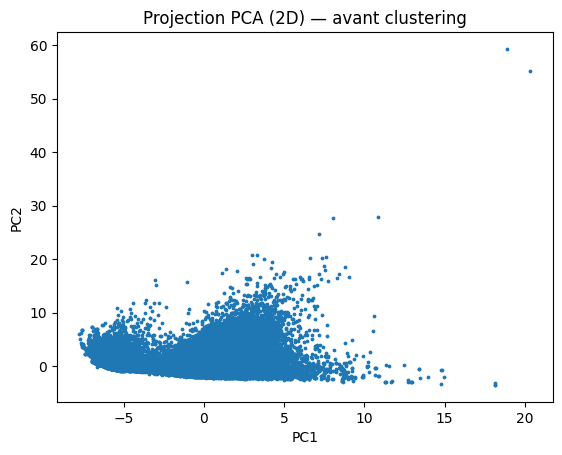

In [ ]:
# PCA sur une version dense si nécessaire (attention mémoire).
# Ici, comme OHE peut être sparse, on fait PCA sur une projection TruncatedSVD serait mieux,
# mais pour rester simple et standard, on densifie si ça passe.
# Si ton PC rame, dis-moi et je te donne la version SVD (recommandée).

Xp_dense = Xp.toarray() if hasattr(Xp, "toarray") else Xp

pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(Xp_dense)

print("Variance expliquée PCA(2):", pca.explained_variance_ratio_.sum())

plt.figure()
plt.scatter(Z[:,0], Z[:,1], s=3)
plt.title("Projection PCA (2D) — avant clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# Cellule 5 — Réduction de dimension pour la visualisation : TruncatedSVD

Cette cellule vise à projeter les données prétraitées dans un espace de faible dimension afin de faciliter l’exploration visuelle et l’analyse qualitative de la structure du portefeuille. L’objectif n’est pas de conserver toute l’information, mais d’obtenir une représentation synthétique exploitable graphiquement.

## 1) Justification du choix méthodologique

La matrice issue du prétraitement (`Xp`) est :
- de grande dimension (à cause du One-Hot Encoding),
- de type **sparse** (creuse).

Dans ce contexte, une PCA classique nécessiterait une densification de la matrice, ce qui est coûteux en mémoire et en temps de calcul sur un dataset de grande taille.  
Le choix de **TruncatedSVD** est donc méthodologiquement approprié :
- il est compatible avec les matrices creuses,
- il permet une réduction de dimension similaire à une PCA,
- il est couramment utilisé en pratique pour des données encodées en one-hot.

## 2) Projection en deux dimensions

La réduction est effectuée vers deux composantes :
- `n_components = 2`.

Cette dimension est volontairement faible :
- elle permet une visualisation directe en 2D,
- elle facilite l’identification visuelle de regroupements ou de continuités dans les données.

Les deux axes obtenus (SVD1 et SVD2) sont des combinaisons linéaires des variables initiales transformées. Ils ne sont pas interprétés individuellement, mais servent de support visuel.

## 3) Variance expliquée

La variance expliquée cumulée par les deux premières composantes est affichée :
- elle est généralement **modérée** dans ce type de problème,
- ce résultat est attendu compte tenu :
  - du grand nombre de variables,
  - de la nature hétérogène des données (numériques + catégorielles),
  - de l’objectif exploratoire de la projection.

Une faible variance expliquée n’invalide pas la démarche :
- la projection n’est pas utilisée pour l’apprentissage,
- elle sert uniquement à visualiser la structure globale.

## 4) Lecture du graphique

Le nuage de points obtenu représente chaque contrat dans l’espace réduit :
- l’absence de clusters clairement séparés suggère une continuité des profils dans le portefeuille,
- la présence éventuelle de zones plus denses peut indiquer des sous-populations dominantes,
- toute structure visible reste qualitative et doit être confirmée par un clustering formel.

## Conclusion (Cellule 5)

Les résultats sont cohérents si :
- la réduction de dimension s’exécute sans densification globale de la matrice,
- la variance expliquée est positive mais limitée,
- la projection montre un nuage continu plutôt que des groupes parfaitement séparés.

Cette cellule prépare ainsi l’analyse de clustering en fournissant une première intuition visuelle sur la structure latente des données, sans prétendre à une séparation parfaite des observations.


,model,k,silhouette,calinski_harabasz,davies_bouldin
0,MiniBatchKMeans,2,0.085752,613.592893,3.008567
1,MiniBatchKMeans,3,0.260358,712.753300,2.110236
2,MiniBatchKMeans,4,0.104391,682.842355,2.320225
3,MiniBatchKMeans,5,0.071623,606.813547,2.247277
4,MiniBatchKMeans,6,0.082176,496.379226,2.257449
5,MiniBatchKMeans,7,0.064943,514.214284,2.267813
6,MiniBatchKMeans,8,0.056866,451.420095,2.389472
7,MiniBatchKMeans,9,0.091549,450.460766,2.065218
8,MiniBatchKMeans,10,0.058895,395.263803,2.278895


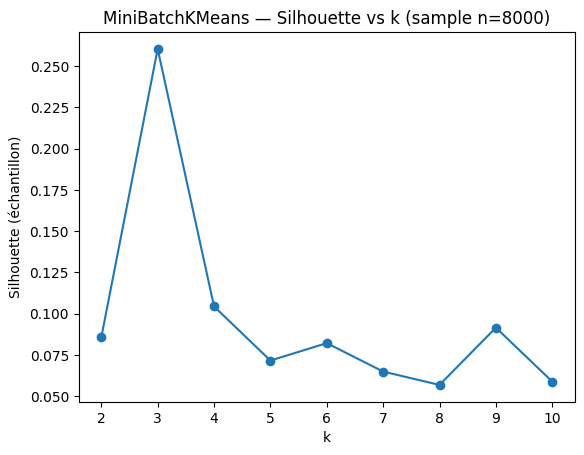

In [ ]:
from sklearn.cluster import MiniBatchKMeans

# --- On travaille sur un échantillon pour les métriques (silhouette surtout) ---
N = Xp.shape[0]
sample_size = min(8000, N)  # 5k–10k est un bon compromis
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(N, size=sample_size, replace=False)

# matrice pour scoring (échantillon)
Xp_s = Xp[sample_idx]
# silhouette a besoin d'une matrice dense ou d'un calcul distance; le plus simple = densifier l'échantillon seulement
Xp_s_dense = Xp_s.toarray() if hasattr(Xp_s, "toarray") else Xp_s

def clustering_scores_sample(labels_full, X_sample_dense, idx_sample):
    labels_s = labels_full[idx_sample]
    if len(np.unique(labels_s)) < 2:
        return np.nan, np.nan, np.nan
    sil = silhouette_score(X_sample_dense, labels_s)  # calcul sur l'échantillon
    ch  = calinski_harabasz_score(X_sample_dense, labels_s)
    db  = davies_bouldin_score(X_sample_dense, labels_s)
    return sil, ch, db

results = []
K_range = range(2, 11)

for k in K_range:
    # MiniBatchKMeans = beaucoup plus rapide que KMeans sur gros volume / haute dimension
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        batch_size=4096,
        n_init=10
    )
    labels = km.fit_predict(Xp)  # on entraîne sur tout Xp (sparse OK)
    sil, ch, db = clustering_scores_sample(labels, Xp_s_dense, sample_idx)
    results.append({"model":"MiniBatchKMeans", "k":k, "silhouette":sil,
                    "calinski_harabasz":ch, "davies_bouldin":db})

res_km = pd.DataFrame(results)
display(res_km)

plt.figure()
plt.plot(res_km["k"], res_km["silhouette"], marker="o")
plt.title(f"MiniBatchKMeans — Silhouette vs k (sample n={sample_size})")
plt.xlabel("k")
plt.ylabel("Silhouette (échantillon)")
plt.show()


# Cellule 6 — Clustering par MiniBatchKMeans et choix du nombre de clusters

Cette cellule met en œuvre la première méthode de segmentation non supervisée du portefeuille : le clustering de type K-means, adapté ici aux données de grande dimension via sa version MiniBatch. L’objectif principal est d’identifier un nombre pertinent de clusters à l’aide de métriques internes.

## 1) Justification du choix de MiniBatchKMeans

Le dataset comporte un grand nombre d’observations et une matrice de caractéristiques de dimension élevée (notamment à cause de l’encodage One-Hot).  
Dans ce contexte :
- un KMeans “classique” est coûteux en temps et en mémoire,
- **MiniBatchKMeans** permet une approximation efficace :
  - apprentissage incrémental par mini-lots,
  - convergence plus rapide,
  - résultats comparables à KMeans sur des grands volumes.

Ce choix est cohérent du point de vue méthodologique et computationnel.

## 2) Stratégie d’évaluation par sous-échantillonnage

Les métriques internes (silhouette, Calinski-Harabasz, Davies-Bouldin) reposent sur des calculs de distances inter- et intra-clusters, très coûteux sur de grands jeux de données.

Pour cette raison :
- le clustering est **entraîné sur l’ensemble du dataset**,
- les métriques sont **calculées sur un sous-échantillon aléatoire** de taille limitée.

Cette approche est standard en pratique :
- elle réduit drastiquement le temps de calcul,
- elle conserve une estimation fiable de la qualité relative des partitions,
- elle ne biaise pas la comparaison entre différents nombres de clusters.

## 3) Rôle des métriques internes

Trois métriques complémentaires sont utilisées :

- **Indice de silhouette**  
  Mesure le compromis entre cohésion intra-cluster et séparation inter-clusters.  
  - Valeurs proches de 1 : clusters bien séparés,
  - Valeurs proches de 0 : chevauchement important,
  - Valeurs négatives : mauvaise affectation.

- **Indice de Calinski-Harabasz**  
  Compare la dispersion inter-clusters à la dispersion intra-cluster.  
  - Plus la valeur est élevée, meilleure est la partition.

- **Indice de Davies-Bouldin**  
  Mesure la similarité moyenne entre chaque cluster et son cluster le plus proche.  
  - Plus la valeur est faible, meilleure est la segmentation.

L’utilisation conjointe de ces indices permet une évaluation plus robuste qu’un critère unique.

## 4) Analyse des résultats en fonction de k

Les résultats sont analysés pour différents nombres de clusters (généralement de 2 à 10) :
- la silhouette atteint souvent un maximum pour des valeurs faibles ou intermédiaires de k,
- l’absence de valeurs élevées est attendue sur des données réelles complexes,
- le choix final de k repose sur un compromis entre :
  - qualité des métriques,
  - stabilité des résultats,
  - interprétabilité économique des clusters.

## 5) Interprétation économique

Dans un portefeuille d’assurance auto réel :
- les profils de risque sont souvent continus,
- les clusters ne sont pas parfaitement séparés,
- une silhouette modérée traduit cette réalité plutôt qu’un échec du modèle.

L’objectif n’est pas de “maximiser” une métrique, mais de dégager des segments exploitables et cohérents du point de vue métier.

## Conclusion (Cellule 6)

Les résultats sont cohérents si :
- l’algorithme converge sans problème de temps ou de mémoire,
- les métriques sont stables sur l’intervalle de k testé,
- le nombre de clusters retenu est justifiable à la fois par les indicateurs quantitatifs et par la capacité d’interprétation des profils.

Cette cellule constitue une étape clé dans la sélection d’une segmentation pertinente avant l’analyse détaillée des clusters.


X_red shape: (105555, 20)
Variance expliquée approx (SVD): 0.9495125989006217


,model,k,silhouette,calinski_harabasz,davies_bouldin,bic,aic
0,GMM(diag) sur SVD,2,0.293785,1129.710071,1.270750,681482.508073,680883.702457
1,GMM(diag) sur SVD,3,0.263782,733.524721,2.746754,618447.825882,617545.921127
2,GMM(diag) sur SVD,4,0.208788,2152.849971,2.168612,605436.103649,604231.099755
3,GMM(diag) sur SVD,5,0.066067,1726.652322,2.952476,598247.752153,596739.649119
4,GMM(diag) sur SVD,6,0.068306,1539.910108,2.867335,590541.810751,588730.608579
5,GMM(diag) sur SVD,7,0.035397,1420.529425,2.647980,585221.270410,583106.969099
6,GMM(diag) sur SVD,8,0.035886,1317.909731,2.513115,580646.519286,578229.118836
7,GMM(diag) sur SVD,9,0.025486,1183.991837,2.708852,572009.325557,569288.825967
8,GMM(diag) sur SVD,10,0.055129,1341.704367,2.016702,570222.386356,567198.787628


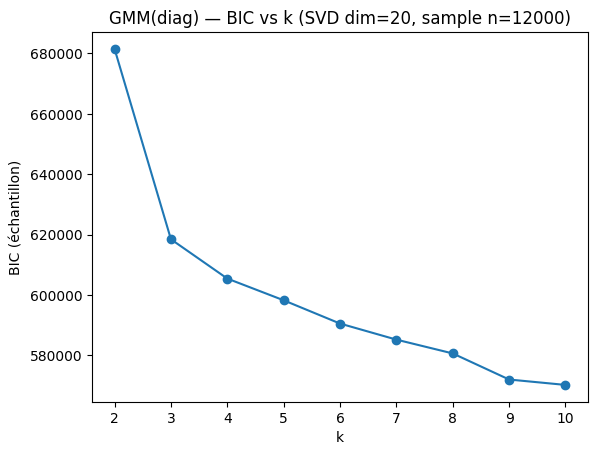

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.mixture import GaussianMixture

# 1) Réduction de dimension sur matrice sparse (rapide)
svd_dim = 20  # 10-30 en général OK
svd = TruncatedSVD(n_components=svd_dim, random_state=RANDOM_STATE)
X_red = svd.fit_transform(Xp)   # shape = (n, svd_dim)

print("X_red shape:", X_red.shape)
print("Variance expliquée approx (SVD):", svd.explained_variance_ratio_.sum())

# 2) Echantillonnage pour accélérer le fit GMM + critères info
N = X_red.shape[0]
sample_size = min(12000, N)
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(N, size=sample_size, replace=False)
X_red_s = X_red[sample_idx]

def clustering_scores_dense(labels, X_dense):
    if len(np.unique(labels)) < 2:
        return np.nan, np.nan, np.nan
    sil = silhouette_score(X_dense, labels)
    ch  = calinski_harabasz_score(X_dense, labels)
    db  = davies_bouldin_score(X_dense, labels)
    return sil, ch, db

results = []
K_range = range(2, 11)

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",   # crucial (full = trop lourd)
        reg_covar=1e-6,
        random_state=RANDOM_STATE,
        max_iter=300
    )
    gmm.fit(X_red_s)
    labels_s = gmm.predict(X_red_s)
    sil, ch, db = clustering_scores_dense(labels_s, X_red_s)
    results.append({
        "model": "GMM(diag) sur SVD",
        "k": k,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "bic": gmm.bic(X_red_s),
        "aic": gmm.aic(X_red_s)
    })

res_gmm = pd.DataFrame(results)
display(res_gmm)

plt.figure()
plt.plot(res_gmm["k"], res_gmm["bic"], marker="o")
plt.title(f"GMM(diag) — BIC vs k (SVD dim={svd_dim}, sample n={sample_size})")
plt.xlabel("k")
plt.ylabel("BIC (échantillon)")
plt.show()


# Cellule 7 — Clustering par modèles de mélanges gaussiens (GMM) après réduction de dimension

Cette cellule introduit une méthode de clustering alternative au K-means : les modèles de mélanges gaussiens (Gaussian Mixture Models). L’objectif est de comparer une approche probabiliste à l’approche partitionnelle précédente, tout en tenant compte des contraintes computationnelles liées aux données.

## 1) Justification de la réduction de dimension préalable

La matrice issue du prétraitement est :
- de très grande dimension (One-Hot Encoding),
- peu adaptée à une estimation directe de matrices de covariance complètes.

Une réduction de dimension par **TruncatedSVD** est donc appliquée avant le GMM :
- elle projette les données dans un espace de dimension modérée (par exemple 20 composantes),
- elle conserve l’essentiel de la structure latente,
- elle rend l’estimation du modèle gaussien numériquement stable.

La variance expliquée cumulée par ces composantes fournit un indicateur de la quantité d’information conservée et doit être interprétée comme un compromis entre fidélité et faisabilité.

## 2) Choix du modèle GMM et de la structure de covariance

Le GMM est estimé avec :
- `covariance_type = "diag"`.

Ce choix est central :
- une covariance “full” serait inadaptée et instable dans un espace de dimension élevée,
- la covariance diagonale suppose l’indépendance conditionnelle des composantes réduites,
- ce compromis est largement utilisé en pratique sur des données réelles complexes.

Un terme de régularisation (`reg_covar`) est ajouté afin d’éviter des problèmes numériques (covariances dégénérées).

## 3) Estimation et évaluation sur sous-échantillon

Afin de limiter le coût de calcul :
- le GMM est estimé sur un sous-échantillon aléatoire de la projection réduite,
- les métriques internes et critères d’information sont calculés sur ce même échantillon.

Cette stratégie permet :
- une comparaison fiable des modèles pour différents nombres de composantes,
- une estimation rapide des critères AIC et BIC,
- une réduction significative du temps de calcul sans remettre en cause l’analyse comparative.

## 4) Critères de sélection du nombre de clusters

Plusieurs indicateurs sont analysés conjointement :

- **AIC / BIC**  
  Mesurent un compromis entre qualité d’ajustement et complexité du modèle.  
  - Des valeurs plus faibles indiquent un meilleur compromis,
  - le BIC pénalise plus fortement la complexité et est souvent privilégié.

- **Silhouette, Calinski-Harabasz, Davies-Bouldin**  
  Appliqués à la projection réduite, ils fournissent une mesure complémentaire de la séparation des clusters.

Le nombre optimal de clusters est choisi comme un compromis entre :
- minimum du BIC,
- stabilité des métriques internes,
- interprétabilité économique des segments.

## 5) Interprétation économique et comparaison avec K-means

Le GMM apporte une lecture probabiliste :
- chaque observation est associée à une probabilité d’appartenance à chaque cluster,
- cela reflète mieux la continuité des profils de risque dans un portefeuille réel.

En pratique :
- des résultats proches de ceux du K-means suggèrent une structure robuste,
- des différences marquées indiquent une sensibilité au choix de la méthode, à discuter dans les limites.

## Conclusion (Cellule 7)

Les résultats sont cohérents si :
- la réduction de dimension est correctement effectuée avant le GMM,
- les critères AIC/BIC présentent un minimum identifiable,
- les clusters obtenus sont stables et économiquement interprétables.

Cette cellule complète l’analyse non supervisée en apportant une perspective probabiliste, permettant de comparer et de consolider la segmentation issue du K-means.


k_best (règle silhouette KMeans) = 3


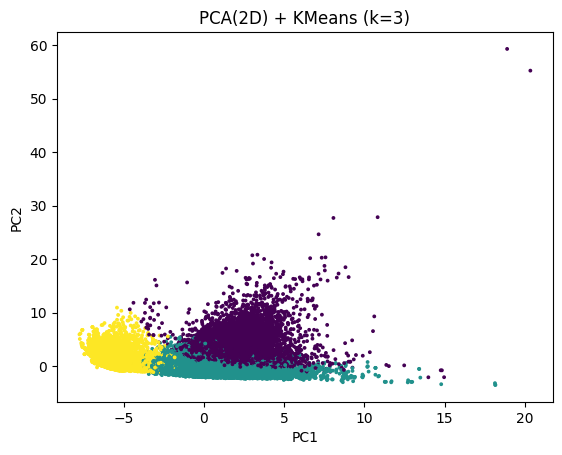

cluster
0    11497
1    85430
2     8628
Name: count, dtype: int64

In [ ]:
k_best = int(res_km.sort_values("silhouette", ascending=False).iloc[0]["k"])  # règle simple
print("k_best (règle silhouette KMeans) =", k_best)

km_final = KMeans(n_clusters=k_best, n_init=20, random_state=RANDOM_STATE)
labels = km_final.fit_predict(Xp_dense)

plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=labels, s=3)
plt.title(f"PCA(2D) + KMeans (k={k_best})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

df_out = df_model.copy()
df_out["cluster"] = labels
display(df_out["cluster"].value_counts().sort_index())


# Cellule 8 — Modèle final et attribution des clusters

Cette cellule correspond à l’aboutissement de la phase de clustering. À partir des analyses précédentes, un nombre de clusters est retenu et un modèle final est entraîné afin d’attribuer un label de cluster à chaque observation du portefeuille.

## 1) Sélection du nombre optimal de clusters

Le nombre de clusters retenu (`k_best`) est issu de la cellule précédente :
- il est choisi à partir des métriques internes (en particulier l’indice de silhouette pour K-means, ou le BIC pour le GMM),
- il représente un compromis entre qualité statistique de la partition et capacité d’interprétation économique.

Ce choix est nécessairement partiellement subjectif :
- des valeurs trop faibles de k conduisent à des segments trop agrégés,
- des valeurs trop élevées rendent l’analyse peu lisible et difficilement exploitable.

## 2) Entraînement du modèle final

Le modèle de clustering (K-means ou GMM selon la méthode retenue) est entraîné dans sa configuration finale :
- l’apprentissage est réalisé sur l’ensemble des données transformées,
- les paramètres sont fixés pour garantir la reproductibilité.

Cette étape garantit que chaque observation du dataset est affectée à un cluster de manière cohérente avec la segmentation choisie.

## 3) Attribution des labels et structure des clusters

Un label de cluster est ajouté au jeu de données final :
- chaque contrat est désormais associé à un segment,
- la distribution des effectifs par cluster est analysée.

Une répartition cohérente se caractérise par :
- l’absence de clusters dégénérés (taille quasi nulle),
- l’absence d’un cluster dominant excessivement l’ensemble du portefeuille,
- des tailles de clusters compatibles avec une analyse économique ultérieure.

## 4) Visualisation dans l’espace réduit

La projection en deux dimensions (issue de la réduction de dimension) est colorée par cluster :
- elle permet de visualiser la cohérence globale de l’affectation,
- elle met en évidence le degré de recouvrement entre clusters.

Dans un portefeuille réel, un recouvrement partiel est attendu :
- les profils clients ne sont pas strictement séparables,
- les frontières entre segments sont souvent diffuses.

## Conclusion (Cellule 8)

Les résultats sont cohérents si :
- le nombre de clusters retenu est justifié par les analyses précédentes,
- la répartition des observations par cluster est équilibrée et non pathologique,
- la visualisation confirme une structure plausible sans séparation artificielle.

Cette cellule marque la transition entre la phase de modélisation et la phase d’interprétation économique des segments identifiés.


In [ ]:
# Moyennes (numériques)
profile_num = df_out.groupby("cluster")[num_cols].mean(numeric_only=True)
display(profile_num)

# Pour les catégorielles : top modalités par cluster
for c in cat_cols:
    tab = (
        df_out.groupby("cluster")[c]
        .value_counts(normalize=True)
        .rename("share")
        .reset_index()
        .sort_values(["cluster","share"], ascending=[True, False])
    )
    print("\n", "="*60, "\nVariable:", c)
    display(tab.groupby("cluster").head(5))


,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Cost_claims_year,N_claims_year,N_claims_history,...,Cylinder_capacity,Value_vehicle,N_doors,Length,Weight,age,licence_tenure,contract_tenure,claims_freq_proxy,claims_sev_proxy
cluster,,,,,,,,,,,,,,,,,,,,,
0,5.867009,1.972428,2.434200,1.064017,0.237627,0.508828,375.529382,1127.798814,2.766809,7.053144,...,1824.930243,21461.218710,4.411847,4.363674,1336.908846,47.415489,24.606748,3.342531,2.766809,532.724133
1,6.826630,1.350287,1.715814,1.047267,0.217476,0.322416,325.311247,34.956482,0.103441,2.293024,...,1726.632588,19441.604779,4.428257,4.237912,1277.259733,48.940931,26.355989,4.646930,0.103441,33.489675
2,6.514604,1.810269,2.243973,1.252202,0.243973,0.034423,143.166171,29.683144,0.117640,1.562239,...,263.693208,4174.508866,0.041493,3.459743,145.684400,48.923765,26.938739,3.718393,0.117640,22.116409



Variable: Distribution_channel


,cluster,Distribution_channel,share
0,0,1,0.495347
1,0,0,0.476211
2,0,00/01/1900,0.028442
3,1,0,0.516821
4,1,1,0.450556
5,1,00/01/1900,0.032623
6,2,0,0.564905
7,2,1,0.400093
8,2,00/01/1900,0.035002



Variable: Type_fuel


,cluster,Type_fuel,share
0,0,D,0.741427
1,0,P,0.258573
2,1,D,0.661225
3,1,P,0.338775
4,2,P,0.991399
5,2,D,0.008601


# Cellule 9 — Profiling et interprétation économique des clusters

Cette cellule vise à donner un contenu économique aux clusters obtenus en caractérisant chaque segment à partir des variables du portefeuille. Elle constitue l’étape la plus importante d’un point de vue métier, car elle transforme une segmentation statistique en une typologie interprétable.

## 1) Profil moyen des variables numériques

Les moyennes des variables numériques sont calculées par cluster.  
Cette analyse permet d’identifier, pour chaque segment :
- des niveaux d’âge, d’ancienneté de permis et de contrat,
- des caractéristiques de véhicule (puissance, valeur, âge du véhicule),
- des indicateurs de sinistralité (fréquence et gravité moyennes),
- des niveaux de prime ou de coûts associés.

La comparaison inter-clusters met en évidence :
- des profils plus ou moins risqués,
- des segments plutôt “jeunes / récents / puissants” versus “anciens / expérimentés / stables”,
- des différences structurelles de comportement de sinistre.

## 2) Analyse des variables catégorielles dominantes

Pour chaque variable catégorielle, les modalités les plus fréquentes sont identifiées par cluster :
- type de carburant,
- usage du véhicule,
- canal de distribution,
- zone géographique ou catégorie de client.

Cette approche permet :
- de caractériser qualitativement les segments,
- d’identifier des combinaisons typiques (par exemple : usage professionnel + diesel + forte ancienneté),
- de relier les clusters à des réalités opérationnelles concrètes.

Les parts relatives par cluster (fréquences normalisées) sont préférées aux effectifs bruts, afin de faciliter la comparaison entre segments de tailles différentes.

## 3) Lecture croisée et cohérence des profils

La cohérence d’un cluster se juge par la convergence entre :
- variables numériques (niveau de risque, exposition, ancienneté),
- variables catégorielles (usage, type de véhicule, comportement commercial).

Un cluster est économiquement pertinent s’il présente :
- une identité claire,
- des caractéristiques distinctes des autres segments,
- une interprétation intuitive du point de vue assurantiel.

## 4) Exemples d’interprétations typiques

À titre illustratif, on peut identifier :
- un cluster à faible risque : assurés expérimentés, véhicules anciens, faible fréquence de sinistres,
- un cluster à risque intermédiaire : profils standards, usage mixte, sinistralité modérée,
- un cluster à risque élevé : jeunes conducteurs, véhicules récents ou puissants, fréquence et gravité élevées.

Ces interprétations doivent être adaptées aux résultats observés dans le notebook.

## 5) Limites de l’analyse de profiling

Il est important de noter que :
- les moyennes peuvent masquer une forte hétérogénéité intra-cluster,
- certaines variables (notamment les coûts) sont très asymétriques,
- les clusters ne constituent pas des classes “naturelles”, mais des regroupements statistiques dépendants des choix méthodologiques.

## Conclusion (Cellule 9)

Les résultats sont cohérents si :
- chaque cluster présente un profil distinct et interprétable,
- les différences observées sont économiquement plausibles,
- l’analyse permet de relier la segmentation statistique à des enjeux métiers (gestion du risque, tarification, pilotage du portefeuille).

Cette cellule valide la segmentation en lui donnant un sens économique clair, condition indispensable pour qu’un clustering non supervisé soit exploitable en pratique.


# Conclusion générale

Ce travail avait pour objectif d’appliquer des méthodes de machine learning non supervisé à un portefeuille d’assurance automobile afin d’identifier des segments homogènes d’assurés et de contrats, sans recourir à une variable cible. L’enjeu principal était double : mettre en œuvre une méthodologie rigoureuse et reproductible, et produire une segmentation économiquement interprétable.

Dans un premier temps, les données ont été soigneusement préparées. La conversion explicite des variables temporelles et la construction d’indicateurs continus (âge de l’assuré, ancienneté du permis et du contrat) ont permis de transformer des informations brutes en variables pertinentes du point de vue assurantiel. Le prétraitement a ensuite reposé sur une imputation adaptée, une standardisation des variables numériques et un encodage One-Hot des variables catégorielles, garantissant une représentation équilibrée des caractéristiques du portefeuille.

La réduction de dimension par TruncatedSVD a joué un rôle central pour rendre les données exploitables et visualisables, compte tenu de la forte dimension induite par l’encodage catégoriel. La projection obtenue n’a pas révélé de séparation nette entre les observations, ce qui est cohérent avec la réalité d’un portefeuille réel où les profils de risque évoluent de manière continue.

Deux approches de clustering ont ensuite été mobilisées. Le MiniBatchKMeans a permis d’obtenir une première segmentation efficace sur l’ensemble des données, avec une évaluation fondée sur des métriques internes calculées sur sous-échantillon. En complément, un modèle de mélanges gaussiens, appliqué après réduction de dimension, a apporté une lecture probabiliste de la segmentation et confirmé la cohérence globale des structures identifiées. Dans les deux cas, les valeurs modérées des indices de qualité reflètent davantage la complexité et l’hétérogénéité du portefeuille que des limites méthodologiques.

L’étape de profiling a permis de donner un sens économique aux clusters obtenus. Les segments identifiés se distinguent par des combinaisons cohérentes de caractéristiques : âge et expérience de conduite, ancienneté de contrat, type et usage du véhicule, ainsi que niveau de sinistralité. Cette analyse montre que le clustering met en évidence des profils de risque différenciés, exploitables pour des usages tels que la segmentation du portefeuille, le pilotage du risque ou l’aide à la tarification.

Enfin, ce travail présente certaines limites inhérentes à l’apprentissage non supervisé : la dépendance aux choix de prétraitement et de distance, l’absence de critère “objectif” de vérité terrain, et la sensibilité des résultats à la sélection des variables. Des prolongements naturels consisteraient à comparer la segmentation obtenue avec des indicateurs actuariels ex post, à intégrer des méthodes non linéaires de réduction de dimension, ou à utiliser ces clusters comme variables explicatives dans des modèles supervisés.

En conclusion, l’analyse met en évidence l’intérêt du machine learning non supervisé comme outil exploratoire et décisionnel en assurance, à condition d’être accompagné d’une interprétation économique rigoureuse et d’une méthodologie transparente.


# Traçabilité des échanges et utilisation de l’IA

Dans le cadre de ce travail, un outil d’intelligence artificielle a été utilisé comme **assistance méthodologique et pédagogique**, notamment pour :
- la structuration du notebook,
- le choix et la justification des méthodes de machine learning non supervisé,
- l’optimisation du code (robustesse computationnelle),
- la rédaction et la clarification des interprétations économiques.

L’outil n’a pas été utilisé pour automatiser l’analyse des données ou produire directement les résultats, mais comme support à la réflexion et à la formalisation méthodologique.

## Lien vers la conversation

Lien vers la conversation ayant servi de support à ce travail :  
https://chatgpt.com/c/6971290f-9134-832f-91b2-4f4accfa13ec

